In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
import pickle

# 1. Load Dataset
news_df = pd.read_csv('politik_merge.csv')

# 2. Drop NA dan gunakan kolom kapital sesuai dataset
news_df = news_df.dropna(subset=['Content'])

# Deteksi format tanggal secara otomatis
news_df['Waktu'] = pd.to_datetime(news_df['Waktu'], errors='coerce')
news_df = news_df.dropna(subset=['Waktu'])

# 3. TF-IDF Vektorisasi
vectorizer = TfidfVectorizer(stop_words=None, max_df=0.7)
tfidf_matrix = vectorizer.fit_transform(news_df['Content'])

# 4. Clustering (opsional)
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
news_df['Cluster'] = kmeans.fit_predict(tfidf_matrix)

# 5. Simpan model dan data
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)

news_df.to_csv('news_with_cluster.csv', index=False)

C:\Users\user\AppData\Local\Temp\ipykernel_16456\459953231.py:14: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  news_df['Waktu'] = pd.to_datetime(news_df['Waktu'], errors='coerce')
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\user\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, 

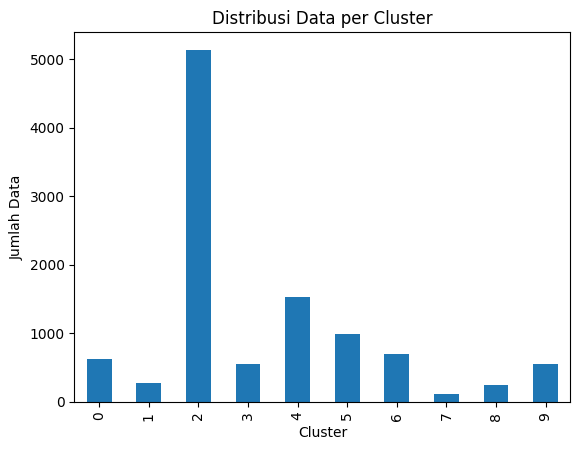

In [4]:
import matplotlib.pyplot as plt

# Plot jumlah data per cluster
news_df['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Data per Cluster')
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_1204\2439284083.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tag_counts.index[:20], y=tag_counts.values[:20], palette="viridis")


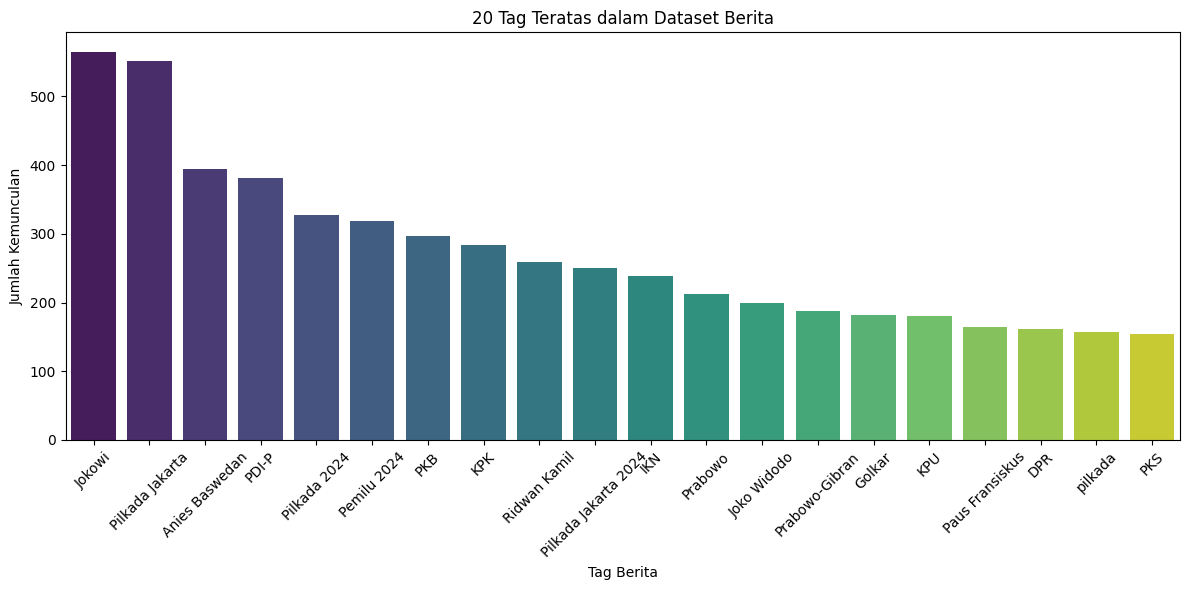

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Baca dataset
df = pd.read_csv("news_with_cluster.csv")

# Gabungkan semua tag jadi satu Series (flatten)
all_tags = pd.concat([df['tag1'], df['tag2'], df['tag3'], df['tag4'], df['tag5']])
tag_counts = all_tags.value_counts().sort_values(ascending=False)

# Visualisasi
plt.figure(figsize=(12,6))
sns.barplot(x=tag_counts.index[:20], y=tag_counts.values[:20], palette="viridis")
plt.title("20 Tag Teratas dalam Dataset Berita")
plt.ylabel("Jumlah Kemunculan")
plt.xlabel("Tag Berita")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
